In [45]:
import requests
import pandas as pd
from selenium import webdriver
from bs4 import BeautifulSoup
import plotly.express as px

In [ ]:
url = "https://www.imdb.com/chart/top/"

driver = webdriver.Chrome()
driver.get(url)
html = driver.page_source

with open("imdb.html", "w", encoding="utf-8") as f:
    f.write(html)

print("HTML Saved Successfully!")

In [46]:
with open("imdb.html","r",encoding="utf-8") as f:
    soup = BeautifulSoup(f,"html.parser")

In [47]:
movies = soup.select("li.ipc-metadata-list-summary-item")

In [48]:
print(len(movies))

250


In [49]:
movie_data = []

for movie in movies:

    title = movie.select_one("h4.ipc-title__text").text.strip()

    metadata = movie.select("li.ipc-inline-list__item")

    year = metadata[0].text.strip()

    duration = metadata[1].text.strip()

    rating = movie.select_one(".ipc-rating-star--rating").text.strip()

    movie_data.append({
        "Title": title,
        "Year": year,
        "Duration": duration,
        "Rating": rating
    })

In [50]:
for movie in movie_data [:10]:
    print(f"{movie["Title"]} ({movie["Year"]}) - Rating: {movie["Rating"]}")

The Shawshank Redemption (1994) - Rating: 9.3
The Godfather (1972) - Rating: 9.2
The Dark Knight (2008) - Rating: 9.1
The Godfather Part II (1974) - Rating: 9.0
12 Angry Men (1957) - Rating: 9.0
The Lord of the Rings: The Return of the King (2003) - Rating: 9.0
Schindler's List (1993) - Rating: 9.0
The Lord of the Rings: The Fellowship of the Ring (2001) - Rating: 8.9
Pulp Fiction (1994) - Rating: 8.8
The Good, the Bad and the Ugly (1966) - Rating: 8.8


In [54]:
df = pd.DataFrame(movie_data)
df

,Title,Year,Duration,Rating
0,The Shawshank Redemption,1994,2h 22m,9.3
1,The Godfather,1972,2h 55m,9.2
2,The Dark Knight,2008,2h 32m,9.1
3,The Godfather Part II,1974,3h 22m,9.0
4,12 Angry Men,1957,1h 36m,9.0
...,...,...,...,...
245,The Passion of Joan of Arc,1928,1h 54m,8.1
246,The Handmaiden,2016,2h 25m,8.1
247,Drishyam,2013,2h 40m,8.4
248,Gangs of Wasseypur,2012,5h 21m,8.2


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Title     250 non-null    object
 1   Year      250 non-null    object
 2   Duration  250 non-null    object
 3   Rating    250 non-null    object
dtypes: object(4)
memory usage: 7.9+ KB


In [17]:
df.describe()

,Title,Year,Duration,Rating
count,250,250,250,250
unique,250,87,103,14
top,The Shawshank Redemption,2004,2h 10m,8.1
freq,1,8,9,70


In [18]:
df.isnull().sum()

Title       0
Year        0
Duration    0
Rating      0
dtype: int64

In [27]:
print(df["Rating"])

0      9.3
1      9.2
2      9.1
3      9.0
4      9.0
      ... 
245    8.1
246    8.1
247    8.4
248    8.2
249    8.3
Name: Rating, Length: 250, dtype: float64


In [23]:
df["Rating"] = df["Rating"].astype(float)

In [28]:
print(df["Rating"])

0      9.3
1      9.2
2      9.1
3      9.0
4      9.0
      ... 
245    8.1
246    8.1
247    8.4
248    8.2
249    8.3
Name: Rating, Length: 250, dtype: float64


In [29]:
df["Year"]

0      1994
1      1972
2      2008
3      1974
4      1957
       ... 
245    1928
246    2016
247    2013
248    2012
249    2023
Name: Year, Length: 250, dtype: object

In [30]:
df["Year"] = df["Year"].astype(int)

In [31]:
df["Year"]

0      1994
1      1972
2      2008
3      1974
4      1957
       ... 
245    1928
246    2016
247    2013
248    2012
249    2023
Name: Year, Length: 250, dtype: int64

In [35]:
df["Duration"]

0      142
1      175
2      152
3      202
4       96
      ... 
245    114
246    145
247    160
248    321
249    122
Name: Duration, Length: 250, dtype: int64

In [34]:
import re

def convert_duration(duration):
    match = re.match(r'(?:(\d+)h)?\s*(?:(\d+)m)?', duration)

    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0

    return hours * 60 + minutes

df["Duration"] = df["Duration"].apply(convert_duration)

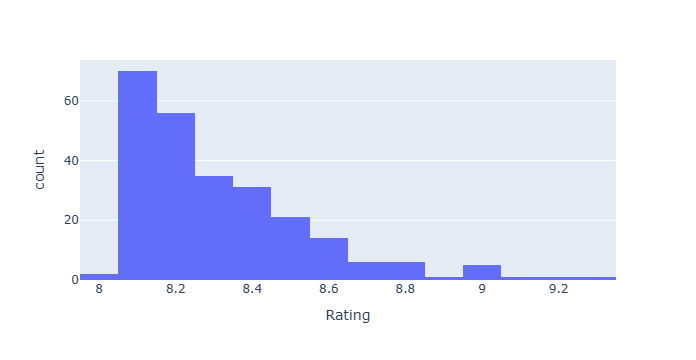

In [36]:
import plotly.express as px

px.histogram(df, x="Rating")

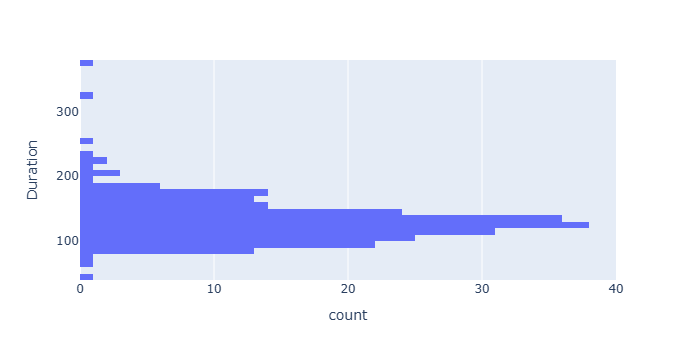

In [37]:
px.histogram(df,y="Duration")

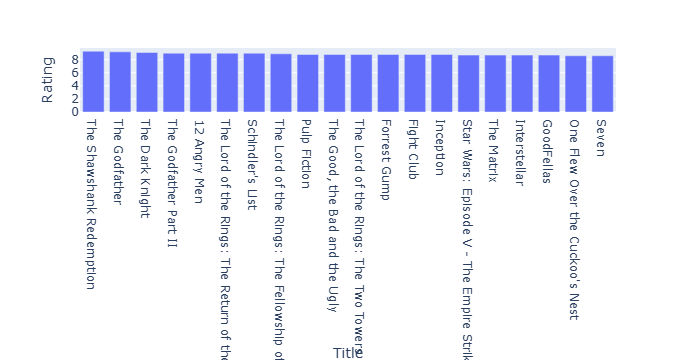

In [40]:
px.bar(
    df.head(20),
    x="Title",
    y="Rating"
)

In [55]:
print("Total Movies :",len(df))

Total Movies : 250


In [58]:
# print("Average Rating :", round(df["Rating"].mean(),2))
# print("Average Runtime :", round(df["Duration"].mean()),"minutes")
# print("Oldest Movie :", df["Year"].min())
# print("Newest Movie :", df["Year"].max())

In [60]:
top10 = df.sort_values(
    "Rating",
    ascending=False
).head(10)

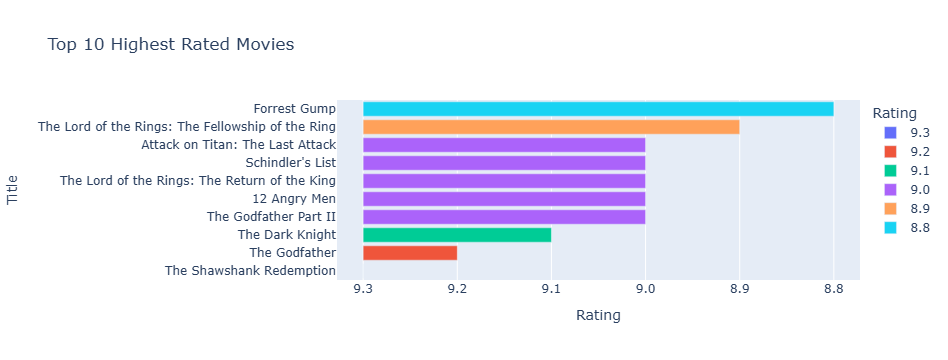

In [61]:
fig = px.bar(
    top10,
    x="Rating",
    y="Title",
    orientation="h",
    color="Rating",
    title="Top 10 Highest Rated Movies"
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})

fig.show()

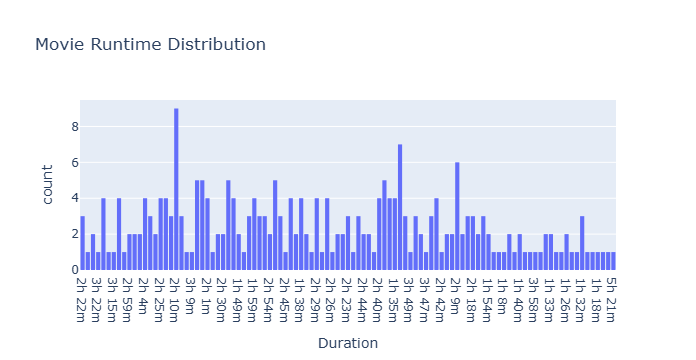

In [63]:
fig = px.histogram(
    df,
    x="Duration",
    nbins=20,
    title="Movie Runtime Distribution"
)

fig.show()

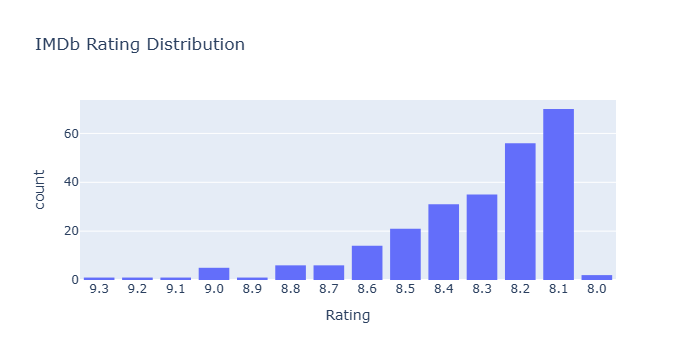

In [64]:
fig = px.histogram(
    df,
    x="Rating",
    nbins=20,
    title="IMDb Rating Distribution"
)

fig.show()

In [67]:
oldest = (
    df.sort_values("Year")
      [["Title","Year","Rating","Duration"]]
      .head(20)
)

oldest

,Title,Year,Rating,Duration
143,The Kid,1921,8.2,1h 8m
207,Sherlock Jr.,1924,8.1,45m
206,The Gold Rush,1925,8.1,1h 35m
213,The General,1926,8.1,1h 18m
121,Metropolis,1927,8.2,2h 30m
245,The Passion of Joan of Arc,1928,8.1,1h 54m
109,M,1931,8.3,1h 39m
54,City Lights,1931,8.5,1h 27m
52,Modern Times,1936,8.5,1h 27m
242,The Wizard of Oz,1939,8.1,1h 42m


In [69]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

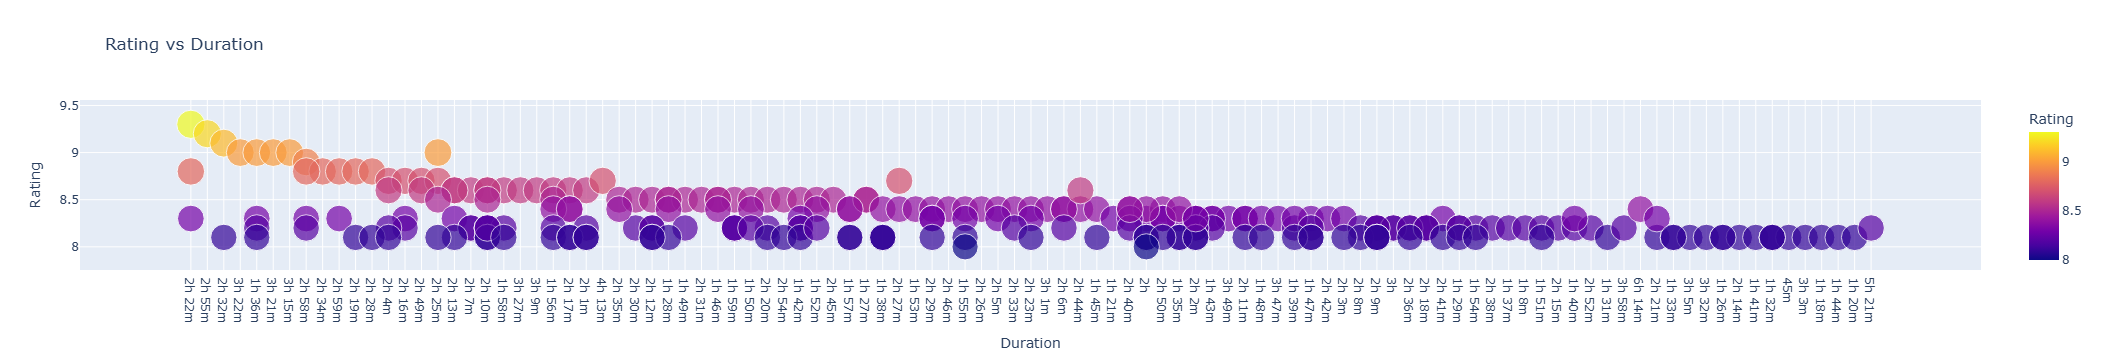

In [70]:
fig = px.scatter(
    df,
    x="Duration",
    y="Rating",
    hover_name="Title",
    color="Rating",
    size="Rating",
    title="Rating vs Duration"
)

fig.show()